### Installing Required Libraries

This cell installs all the Python libraries needed for this project.  
These include libraries for deep learning (PyTorch), transformers (Hugging Face), datasets, and machine learning evaluation.  
Installing them ensures the notebook can run correctly in Google Colab or Jupyter


In [ ]:
!pip install datasets transformers scikit-learn torch


### Importing Python Libraries

This cell imports all the required libraries used throughout the notebook.  
These libraries help with data loading, model training, evaluation, and visualisation.  
Importing everything at the beginning keeps the workflow organised and reproducible.

In [ ]:
import torch
import numpy as np
import pandas as pd
from datasets import load_dataset
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from transformers.optimization import get_linear_schedule_with_warmup

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression


### Loading the Dataset

This cell loads the AG News dataset using the Hugging Face `datasets` library.  
The dataset contains news articles classified into four categories: World, Sports, Business, and Sci/Tech.  
It is automatically split into training and testing sets.


In [ ]:
from datasets import load_dataset

dataset = load_dataset("ag_news")
dataset


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

### Initialising the Tokenizer

This cell loads the pre-trained BERT tokenizer (`bert-base-uncased`).  
The tokenizer converts raw text into numerical tokens that can be understood by the BERT model.  
It also ensures the text format matches the model’s expected input.


In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

### Tokenising and Formatting the Dataset

This cell defines a function that converts raw text into tokens using the BERT tokenizer.  
Each text sample is padded or truncated to a fixed length of 128 tokens so that all inputs have the same size.  

The tokenisation function is applied to the entire dataset using the `map` method.  
The label column is then renamed to match the format expected by the BERT model.  
Finally, the dataset is converted into PyTorch tensors so it can be used directly for training and evaluation.


In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize, batched=True)
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

### Loading the BERT Model for Text Classification

This cell loads a pre-trained BERT model (`bert-base-uncased`) that is designed for sequence (text) classification tasks.  
The model is configured to output predictions for 4 different classes, which match the four categories in the AG News dataset.  
Using a pre-trained BERT model allows us to fine-tune it on our dataset instead of training a model from scratch, which saves time and improves performance.



In [ ]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=4
)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Defining Training Configuration

This cell sets the training parameters for fine-tuning the BERT model using Hugging Face’s `TrainingArguments`.  
It specifies where to save the training outputs, how often the model is evaluated, and how the model learns.  

The learning rate controls how much the model updates its weights during training.  
Batch size defines how many samples are processed at once, and the number of epochs determines how many times the model sees the full training dataset.  
Weight decay is used to reduce overfitting and improve generalisation.


In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01
)

### Defining Evaluation Metrics

This cell defines a function that calculates evaluation metrics for the model during testing.  
The model’s raw output scores (logits) are converted into predicted class labels by selecting the class with the highest score.  

The function then calculates accuracy, precision, recall, and F1 score using the true labels and predicted labels.  
These metrics provide a detailed understanding of the model’s performance beyond just accuracy and are used during evaluation by the Trainer.


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted")
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

### Initialising and Training the Model

This cell creates a Hugging Face `Trainer` object that manages the entire training process.  
It connects the BERT model with the training settings, tokenised training data, test data, and evaluation metrics.  

After initialisation, the `train()` method is called to fine-tune the BERT model on the training dataset.  
The Trainer automatically handles batching, optimisation, and evaluation during training.


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    compute_metrics=compute_metrics
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.200600,0.180079,0.942500,0.943007,0.942500,0.942467
2,0.132800,0.196103,0.944342,0.944605,0.944342,0.944432
3,0.080700,0.240346,0.946053,0.946233,0.946053,0.946115


TrainOutput(global_step=22500, training_loss=0.14994259541829427, metrics={'train_runtime': 9539.9291, 'train_samples_per_second': 37.736, 'train_steps_per_second': 2.359, 'total_flos': 2.368042020864e+16, 'train_loss': 0.14994259541829427, 'epoch': 3.0})

### Evaluating the Trained Model

This cell evaluates the fine-tuned BERT model on the test dataset.  
It calculates the final performance metrics such as accuracy, precision, recall, and F1 score using unseen data.  
This evaluation shows how well the model generalises beyond the training data.


In [ ]:
trainer.evaluate()

{'eval_loss': 0.24034568667411804,
 'eval_accuracy': 0.9460526315789474,
 'eval_precision': 0.9462331256672987,
 'eval_recall': 0.9460526315789474,
 'eval_f1': 0.946114572415678,
 'eval_runtime': 59.4336,
 'eval_samples_per_second': 127.874,
 'eval_steps_per_second': 7.992,
 'epoch': 3.0}

### Preparing Data for Baseline Model

This cell extracts the raw text and labels from the AG News dataset for both training and testing.  
These will be used to train a traditional machine learning model (Logistic Regression with TF-IDF features) as a baseline.  
Unlike BERT, this approach does not use tokenisation or deep learning.


In [ ]:
train_texts = dataset["train"]["text"]
train_labels = dataset["train"]["label"]

test_texts = dataset["test"]["text"]
test_labels = dataset["test"]["label"]


### Converting Text to TF-IDF Features

This cell converts the raw text data into numerical feature vectors using TF-IDF (Term Frequency-Inverse Document Frequency).  
TF-IDF measures how important each word is in a document relative to the entire dataset.  

`max_features=20000` limits the number of features to the 20,000 most important words.  
`fit_transform` is applied to the training data to learn the vocabulary, and `transform` is applied to the test data using the same vocabulary.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=20000)
X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)


### Training the Baseline Logistic Regression Model

This cell trains a traditional machine learning model, Logistic Regression, using the TF-IDF features from the training data.  
`max_iter=2000` sets the maximum number of iterations for the solver to ensure the model converges.  

The model learns to classify news articles into the four categories based on the word features.  
This baseline model is used to compare performance against the fine-tuned BERT model.


In [ ]:
from sklearn.linear_model import LogisticRegression

baseline_clf = LogisticRegression(max_iter=2000)
baseline_clf.fit(X_train, train_labels)


LogisticRegression(max_iter=2000)

### Evaluating the Baseline Model

This cell uses the trained Logistic Regression model to make predictions on the test data.  
The `classification_report` function then calculates and prints detailed performance metrics, including precision, recall, F1 score, and support for each news category.  

This helps to understand how well the baseline model performs before comparing it with BERT.


In [ ]:
from sklearn.metrics import classification_report

baseline_preds = baseline_clf.predict(X_test)
print(classification_report(test_labels, baseline_preds))


              precision    recall  f1-score   support

           0       0.93      0.91      0.92      1900
           1       0.96      0.98      0.97      1900
           2       0.89      0.88      0.89      1900
           3       0.89      0.90      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



### Visualising BERT Training Performance and Confusion Matrix

This cell does two things:

1. **Training Trend Plot**  
   - It extracts the training loss and evaluation accuracy logged during BERT fine-tuning.  
   - Converts training loss into a “pseudo-accuracy” (1 - loss) to visualise how the model improved over epochs.  
   - Plots both the training trend and evaluation accuracy to see how the model learned over time.

2. **Confusion Matrix for BERT**  
   - Uses the trained BERT model to make predictions on the test dataset.  
   - Calculates the final test accuracy.  
   - Creates a confusion matrix to show how often each news category was correctly or incorrectly predicted.  
   - Visualises the confusion matrix using a heatmap for easy interpretation.


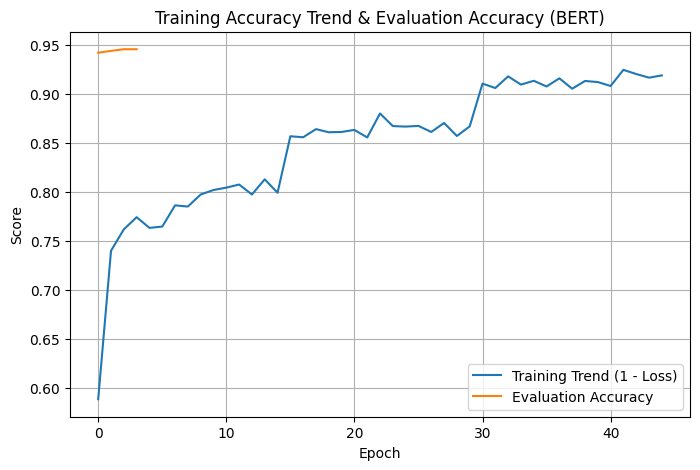

Final Test Accuracy: 0.9460526315789474


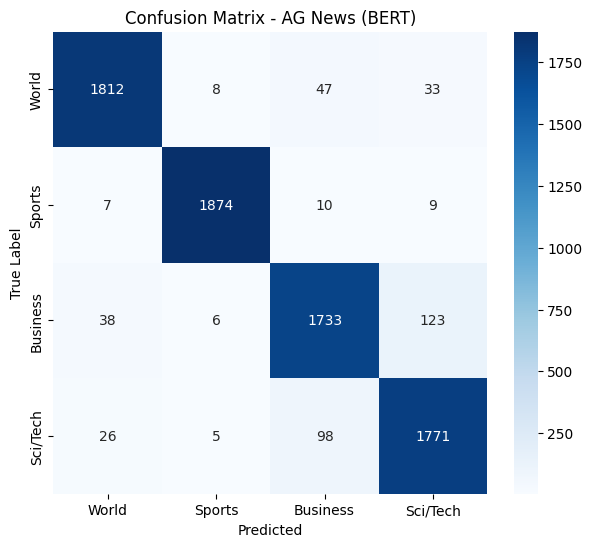

In [ ]:


import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import seaborn as sns
import torch


#  Accuracy Curve Plot

train_acc = []
eval_acc = []

for log in trainer.state.log_history:
    if "eval_accuracy" in log:
        eval_acc.append(log["eval_accuracy"])
    if "loss" in log and "epoch" in log:
        # Convert loss to "pseudo-accuracy" just to visualize training trend.
        # (Loss is not accuracy, but useful to see if training stabilises)
        train_acc.append(1 - log["loss"])

# Plot the curves
plt.figure(figsize=(8,5))
plt.plot(train_acc, label="Training Trend (1 - Loss)")
plt.plot(eval_acc, label="Evaluation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Training Accuracy Trend & Evaluation Accuracy (BERT)")
plt.legend()
plt.grid(True)
plt.show()


# Confusion Matrix

# Create PyTorch DataLoader
test_dataset = tokenized_dataset["test"]

# Get predictions
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# Calculate accuracy
print("Final Test Accuracy:", accuracy_score(labels, preds))

# Confusion Matrix
cm = confusion_matrix(labels, preds)
labels_names = ["World", "Sports", "Business", "Sci/Tech"]

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_names, yticklabels=labels_names)
plt.title("Confusion Matrix - AG News (BERT)")
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.show()


### Confusion Matrix for Baseline Model

This cell visualises the performance of the Logistic Regression baseline model using a confusion matrix.  
- `baseline_preds` are the model's predictions on the test dataset.  
- `test_labels` are the true labels.  

The confusion matrix shows how often each news category was correctly or incorrectly predicted by the baseline model.  
A heatmap is used to make it easier to compare the results visually.  
This helps identify which classes the baseline model struggles with compared to BERT.


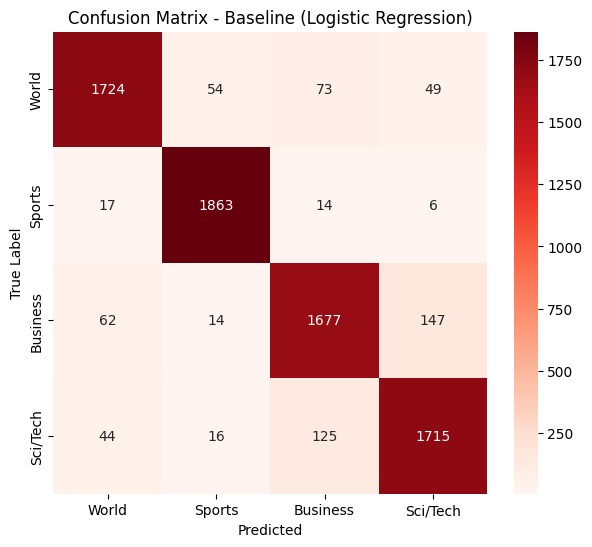

In [ ]:


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions already created as: baseline_preds
# Ground-truth labels: test_labels

cm_baseline = confusion_matrix(test_labels, baseline_preds)
labels_names = ["World", "Sports", "Business", "Sci/Tech"]

plt.figure(figsize=(7,6))
sns.heatmap(cm_baseline, annot=True, fmt="d", cmap="Reds",
            xticklabels=labels_names, yticklabels=labels_names)
plt.title("Confusion Matrix - Baseline (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.show()


### Comparing Accuracy of Baseline and BERT Models

This cell compares the overall accuracy of the Logistic Regression baseline model and the fine-tuned BERT model.  
- `baseline_accuracy` is calculated from the predictions of the baseline model.  
- `bert_accuracy` is taken from the evaluation logs of BERT.  

A bar chart is plotted to visually show the difference in accuracy between the two models.  
The accuracies are also printed for easy reference.


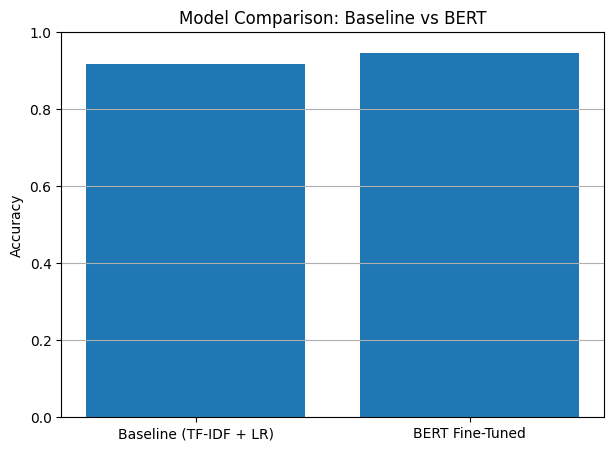

Baseline Accuracy: 0.9182894736842105
BERT Accuracy: 0.9460526315789474


In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


bert_accuracy = log["eval_accuracy"]
baseline_accuracy = accuracy_score(test_labels, baseline_preds)

models = ["Baseline (TF-IDF + LR)", "BERT Fine-Tuned"]
accuracies = [baseline_accuracy, bert_accuracy]

plt.figure(figsize=(7,5))
plt.bar(models, accuracies)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Comparison: Baseline vs BERT")
plt.grid(axis='y')
plt.show()

print("Baseline Accuracy:", baseline_accuracy)
print("BERT Accuracy:", bert_accuracy)

### Comparing Detailed Metrics of Baseline and BERT Models

This cell compares the performance of the Logistic Regression baseline and the fine-tuned BERT model using multiple metrics:

1. **Precision, Recall, and F1 Score Calculation**  
   - For the baseline model, these metrics are calculated using `precision_recall_fscore_support`.  
   - For BERT, the metrics are taken from the evaluation logs.

2. **F1 Score Comparison Plot**  
   - A bar chart compares the F1 scores of the baseline and BERT models to see which model performs better overall.

3. **Precision & Recall Comparison Plot**  
   - Another bar chart compares precision and recall for both models.  
   - This helps to understand how accurately and consistently each model predicts the correct categories.

4. **Performance Summary Table**  
   - A summary table is created showing Accuracy, Precision, Recall, and F1 Score for both models.  
   - This provides a clear, side-by-side comparison of all evaluation metrics.

Overall, this cell gives a complete view of how BERT outperforms the baseline model across multiple performance measures.


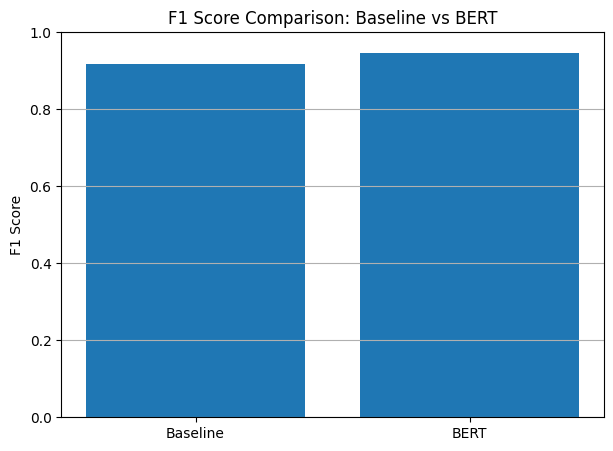

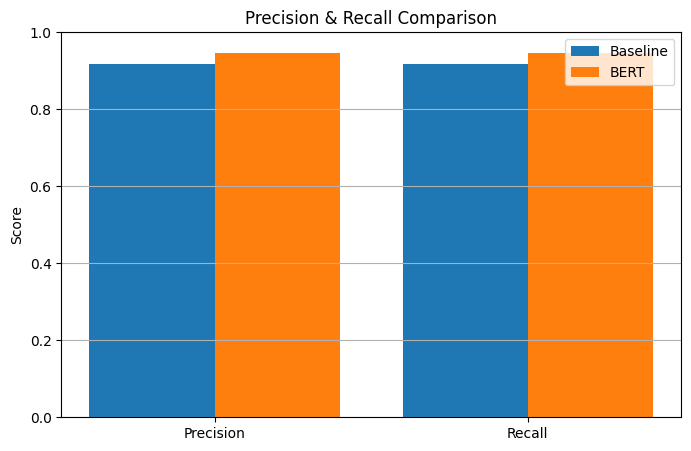


=== PERFORMANCE SUMMARY TABLE ===

                    Model  Accuracy  Precision    Recall  F1 Score
0  Baseline (TF-IDF + LR)  0.918289   0.918165  0.918289  0.918139
1         BERT Fine-Tuned  0.946053   0.946233  0.946053  0.946115


,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline (TF-IDF + LR),0.918289,0.918165,0.918289,0.918139
1,BERT Fine-Tuned,0.946053,0.946233,0.946053,0.946115


In [ ]:


import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support


# Collect Metrics for Both Models


# BASELINE METRICS
baseline_precision, baseline_recall, baseline_f1, _ = precision_recall_fscore_support(
    test_labels, baseline_preds, average='weighted'
)

# BERT METRICS
bert_precision = log["eval_precision"]
bert_recall = log["eval_recall"]
bert_f1 = log["eval_f1"]


# F1 SCORE COMPARISON GRAPH

plt.figure(figsize=(7,5))
plt.bar(["Baseline", "BERT"], [baseline_f1, bert_f1])
plt.ylim(0, 1)
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison: Baseline vs BERT")
plt.grid(axis='y')
plt.show()


#PRECISION & RECALL COMPARISON GRAPH
metrics = ["Precision", "Recall"]
baseline_scores = [baseline_precision, baseline_recall]
bert_scores = [bert_precision, bert_recall]

x = range(len(metrics))
plt.figure(figsize=(8,5))
plt.bar([i - 0.2 for i in x], baseline_scores, width=0.4, label="Baseline")
plt.bar([i + 0.2 for i in x], bert_scores, width=0.4, label="BERT")
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Precision & Recall Comparison")
plt.legend()
plt.grid(axis='y')
plt.show()


# PERFORMANCE SUMMARY TABLE

summary_data = {
    "Model": ["Baseline (TF-IDF + LR)", "BERT Fine-Tuned"],
    "Accuracy": [baseline_accuracy, log["eval_accuracy"]],
    "Precision": [baseline_precision, bert_precision],
    "Recall": [baseline_recall, bert_recall],
    "F1 Score": [baseline_f1, bert_f1]
}

summary_df = pd.DataFrame(summary_data)
print("\n=== PERFORMANCE SUMMARY TABLE ===\n")
print(summary_df)

summary_df